# Music recommendation based on genre, mode, tempo using ML pipeline, evaluation and Hyperparameter tuning

### Prepared by: Udita Bose <uditab@student.unimelb.edu.au>

In [1]:

# import numpy, pandas, graphs
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
# import scikit libraries
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.tree import (
    DecisionTreeClassifier,
    plot_tree
)
from sklearn.neural_network import MLPClassifier
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import StackingClassifier

from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import (
    RobustScaler,
    LabelEncoder,
    OneHotEncoder,
    StandardScaler
)
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    precision_score,
    classification_report,
    ConfusionMatrixDisplay
)
from sklearn.model_selection import (
    validation_curve,
    train_test_split,
    StratifiedKFold,
    GridSearchCV
)
from sklearn.feature_selection import (
    mutual_info_classif,
    SelectKBest
)

from sklearn.pipeline import Pipeline


In [3]:
# import kagglehub
import kagglehub
from kagglehub import KaggleDatasetAdapter

In [4]:
# load the dataset in a Panda DataFrame
all_music_data_df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "vicsuperman/prediction-of-music-genre",
    "music_genre.csv"
)


### Initial Data Exploration

In [5]:
# first few rows
all_music_data_df.head()

,instance_id,artist_name,track_name,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,obtained_date,valence,music_genre
0,32894.0,Röyksopp,Röyksopp's Night Out,27.0,0.00468,0.652,-1.0,0.941,0.79200,A#,0.115,-5.201,Minor,0.0748,100.889,4-Apr,0.759,Electronic
1,46652.0,Thievery Corporation,The Shining Path,31.0,0.01270,0.622,218293.0,0.890,0.95000,D,0.124,-7.043,Minor,0.0300,115.00200000000001,4-Apr,0.531,Electronic
2,30097.0,Dillon Francis,Hurricane,28.0,0.00306,0.620,215613.0,0.755,0.01180,G#,0.534,-4.617,Major,0.0345,127.994,4-Apr,0.333,Electronic
3,62177.0,Dubloadz,Nitro,34.0,0.02540,0.774,166875.0,0.700,0.00253,C#,0.157,-4.498,Major,0.2390,128.014,4-Apr,0.270,Electronic
4,24907.0,What So Not,Divide & Conquer,32.0,0.00465,0.638,222369.0,0.587,0.90900,F#,0.157,-6.266,Major,0.0413,145.036,4-Apr,0.323,Electronic


In [6]:
# basic statistics
# all_music_data_df = all_music_data_df.drop(columns=["instance_id"])
all_music_data_df.head()
all_music_data_df.describe()

,instance_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,valence
count,50000.000000,50000.000000,50000.000000,50000.000000,5.000000e+04,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,55888.396360,44.220420,0.306383,0.558241,2.212526e+05,0.599755,0.181601,0.193896,-9.133761,0.093586,0.456264
std,20725.256253,15.542008,0.341340,0.178632,1.286720e+05,0.264559,0.325409,0.161637,6.162990,0.101373,0.247119
min,20002.000000,0.000000,0.000000,0.059600,-1.000000e+00,0.000792,0.000000,0.009670,-47.046000,0.022300,0.000000
25%,37973.500000,34.000000,0.020000,0.442000,1.748000e+05,0.433000,0.000000,0.096900,-10.860000,0.036100,0.257000
50%,55913.500000,45.000000,0.144000,0.568000,2.192810e+05,0.643000,0.000158,0.126000,-7.276500,0.048900,0.448000
75%,73863.250000,56.000000,0.552000,0.687000,2.686122e+05,0.815000,0.155000,0.244000,-5.173000,0.098525,0.648000
max,91759.000000,99.000000,0.996000,0.986000,4.830606e+06,0.999000,0.996000,1.000000,3.744000,0.942000,0.992000


In [7]:
# correlations existing in the raw data
all_correlation = all_music_data_df.corr(method="pearson", numeric_only=True)
print(f"Correlation of all data: \n{all_correlation}")

Correlation of all data: 
                  instance_id  popularity  acousticness  danceability  \
instance_id          1.000000    0.006317     -0.005268      0.000372   
popularity           0.006317    1.000000     -0.290453      0.356420   
acousticness        -0.005268   -0.290453      1.000000     -0.347681   
danceability         0.000372    0.356420     -0.347681      1.000000   
duration_ms         -0.005848   -0.083809      0.061862     -0.155507   
energy               0.009952    0.216345     -0.791250      0.263934   
instrumentalness    -0.004015   -0.364960      0.387970     -0.301277   
liveness             0.004737   -0.039468     -0.109220     -0.051465   
loudness             0.006847    0.317941     -0.730401      0.390859   
speechiness         -0.005908    0.224309     -0.163377      0.279767   
valence              0.005385    0.124913     -0.270238      0.434557   

                  duration_ms    energy  instrumentalness  liveness  loudness  \
instance_id     

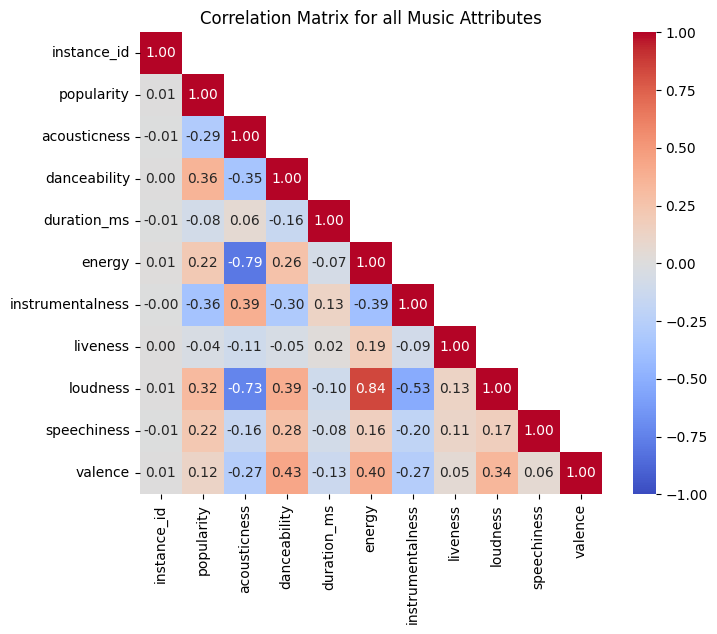

In [8]:
# correlation plotted
mask = np.triu(np.ones_like(all_correlation, dtype=float), k=1)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(all_correlation, mask=mask, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1, square=True)
plt.title("Correlation Matrix for all Music Attributes")
plt.show()

In [9]:
# data shape
all_music_data_df.shape

(50005, 18)

In [10]:
# columns, and data types
all_music_data_df.dtypes

instance_id         float64
artist_name             str
track_name              str
popularity          float64
acousticness        float64
danceability        float64
duration_ms         float64
energy              float64
instrumentalness    float64
key                     str
liveness            float64
loudness            float64
mode                    str
speechiness         float64
tempo                   str
obtained_date           str
valence             float64
music_genre             str
dtype: object

In [11]:
# raw data per genre
all_music_data_df['music_genre'].value_counts()

music_genre
Electronic     5000
Anime          5000
Jazz           5000
Alternative    5000
Country        5000
Rap            5000
Blues          5000
Rock           5000
Classical      5000
Hip-Hop        5000
Name: count, dtype: int64

In [12]:
# unavailable data per feature
all_music_data_df.isna().sum()

instance_id         5
artist_name         5
track_name          5
popularity          5
acousticness        5
danceability        5
duration_ms         5
energy              5
instrumentalness    5
key                 5
liveness            5
loudness            5
mode                5
speechiness         5
tempo               5
obtained_date       5
valence             5
music_genre         5
dtype: int64

In [13]:
# unavailable data per feature
all_music_data_df['danceability'].value_counts()

danceability
0.5290    143
0.6570    139
0.6100    134
0.5540    133
0.4990    130
         ... 
0.0792      1
0.0832      1
0.0708      1
0.9860      1
0.9740      1
Name: count, Length: 1088, dtype: int64

In [14]:
# unique data for string columns
columns = ['key','mode','tempo']
for column in columns:
    print(f"    {column}: {all_music_data_df[column].unique()}")
    print()

    key: <StringArray>
['A#', 'D', 'G#', 'C#', 'F#', 'B', 'G', 'F', 'A', 'C', 'E', 'D#', nan]
Length: 13, dtype: str

    mode: <StringArray>
['Minor', 'Major', nan]
Length: 3, dtype: str

    tempo: <StringArray>
[           '100.889', '115.00200000000001',            '127.994',
            '128.014',            '145.036',                  '?',
            '149.995',            '120.008', '149.94799999999998',
            '139.933',
 ...
            '175.903',             '93.758',             '83.881',
            '128.194',            '138.964',            '129.939',
            '129.285',             '112.97',            '167.655',
  '99.20100000000001']
Length: 29395, dtype: str



In [15]:
# find any duplicated data
duplicated = all_music_data_df.duplicated()
print(f"duplicated : {all_music_data_df[duplicated]}")

duplicated :        instance_id artist_name track_name  popularity  acousticness  \
10001          NaN         NaN        NaN         NaN           NaN   
10002          NaN         NaN        NaN         NaN           NaN   
10003          NaN         NaN        NaN         NaN           NaN   
10004          NaN         NaN        NaN         NaN           NaN   

       danceability  duration_ms  energy  instrumentalness  key  liveness  \
10001           NaN          NaN     NaN               NaN  NaN       NaN   
10002           NaN          NaN     NaN               NaN  NaN       NaN   
10003           NaN          NaN     NaN               NaN  NaN       NaN   
10004           NaN          NaN     NaN               NaN  NaN       NaN   

       loudness mode  speechiness tempo obtained_date  valence music_genre  
10001       NaN  NaN          NaN   NaN           NaN      NaN         NaN  
10002       NaN  NaN          NaN   NaN           NaN      NaN         NaN  
10003       Na

In [16]:
only_mode_music = all_music_data_df[['track_name', 'mode', 'music_genre', 'popularity']]
only_mode_music.head()

,track_name,mode,music_genre,popularity
0,Röyksopp's Night Out,Minor,Electronic,27.0
1,The Shining Path,Minor,Electronic,31.0
2,Hurricane,Major,Electronic,28.0
3,Nitro,Major,Electronic,34.0
4,Divide & Conquer,Major,Electronic,32.0


## Visualize data

/var/folders/1w/jl4qlcr169z42fh_0319qljh0000gn/T/ipykernel_65351/205126863.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = 'mode', data = all_music_data_df, palette = "ocean", order = None)


Text(0.5, 1.0, 'Counts in each mode')

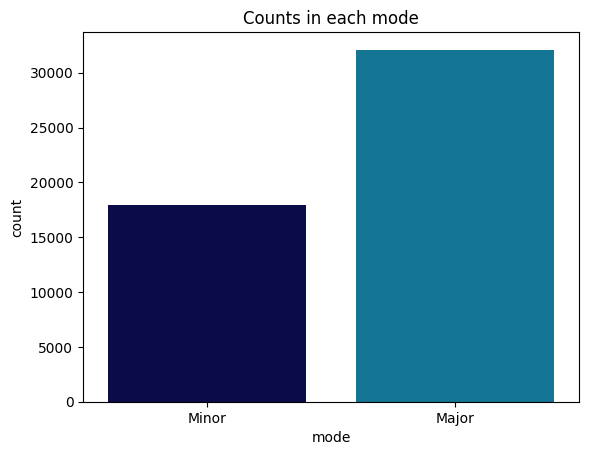

In [17]:
sns.countplot(x = 'mode', data = all_music_data_df, palette = "ocean", order = None)
plt.title(f"Counts in each mode")


All keys: <StringArray>
['A#', 'D', 'G#', 'C#', 'F#', 'B', 'G', 'F', 'A', 'C', 'E', 'D#', nan]
Length: 13, dtype: str



/var/folders/1w/jl4qlcr169z42fh_0319qljh0000gn/T/ipykernel_65351/4043498728.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = 'key', data = all_music_data_df, palette = "ocean", order = None)


Text(0.5, 1.0, 'Counts in each key')

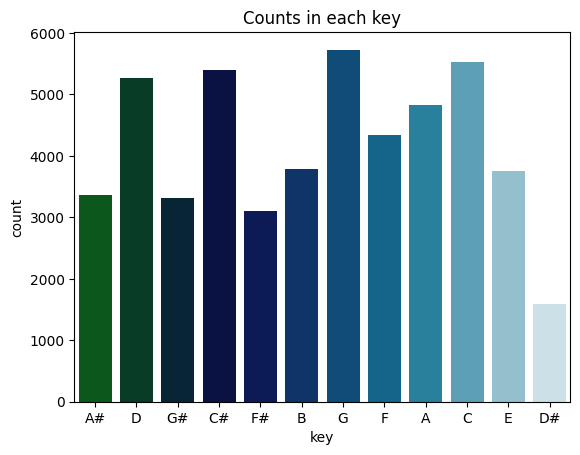

In [18]:
keys_of_music = all_music_data_df['key'].unique()
print(f"All keys: {keys_of_music}")
print()
sns.countplot(x = 'key', data = all_music_data_df, palette = "ocean", order = None)
plt.title(f"Counts in each key")

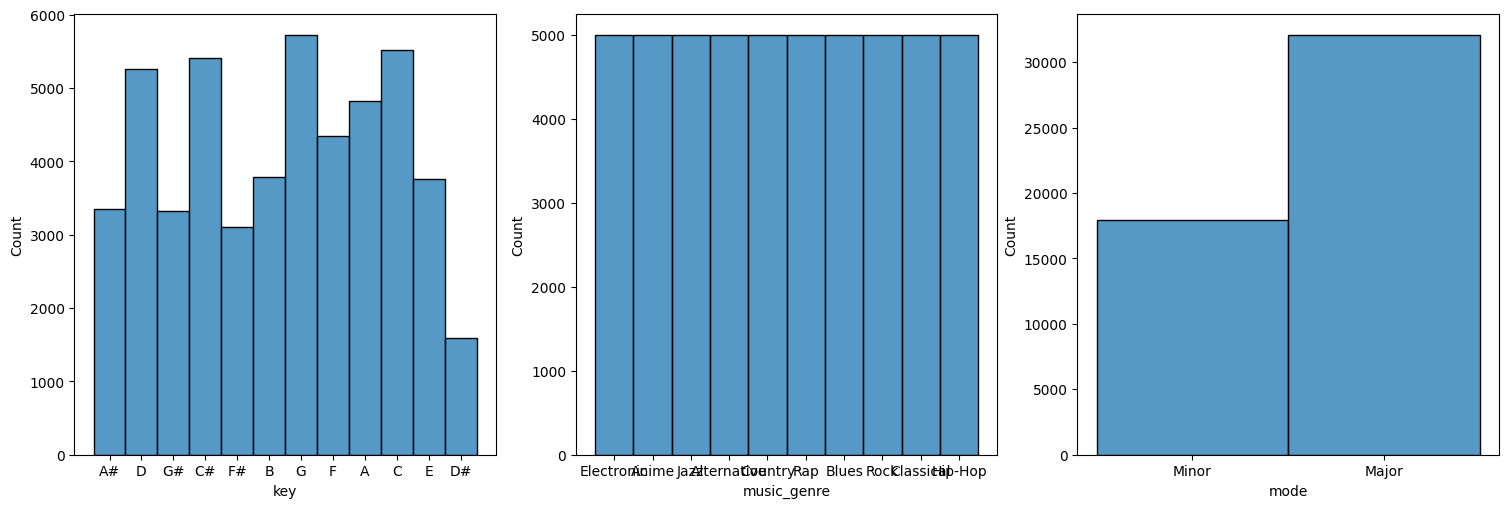

In [19]:
fig, axs = plt.subplots(ncols = 3, nrows = 1, figsize = (15, 5))
# fig.delaxes(axs[2][0])
index = 0

str_features = all_music_data_df[["key", "music_genre", "mode"]]

axs = axs.flatten()
for k, v in str_features.items():
    sns.histplot(v, ax = axs[index])
    index += 1
plt.tight_layout(pad = 0.4, w_pad = 0.5, h_pad = 5.0)

In [20]:
# numeric_features = all_music_data_df.drop(["key", "music_genre", "mode"], axis = 1)
# fig, axs = plt.subplots(ncols = 3, nrows = 4, figsize = (15, 15))
# fig.delaxes(axs[3][2])
# index = 0
#
# axs = axs.flatten()
# for k, v in numeric_features.items():
#     if index < 12:
#         sns.histplot(v, ax = axs[index])
#         index += 1
# plt.tight_layout(pad = 0.4, w_pad = 0.5, h_pad = 5.0)

## Preprocess Data

### Copy Data for future usages, and drop bad data

In [21]:
# copy the data
processed_df = all_music_data_df.copy()
print(f"Initial data shape: {processed_df.shape}")

Initial data shape: (50005, 18)


In [22]:
# drop rows with bad values, Thanks to Zed
bad_values = ['', ' ', '?' , -1 , '-1']
rows_to_drop = processed_df.isna() | processed_df.isin(bad_values)
processed_df = processed_df[~rows_to_drop.any(axis=1)]
print(f"Data shape after dropping bad data: {processed_df.shape}")

Data shape after dropping bad data: (40560, 18)


In [23]:
# drop duplicated rows, from Zed
duplicate_rows = processed_df.duplicated()
if duplicate_rows.sum() > 0:
    print(f"Duplicate rows: \n{processed_df[duplicate_rows]}")
    processed_df = processed_df.drop_duplicates().reset_index(drop=True)

print(f"Data shape after dropping duplicated data: {processed_df.shape}")

Data shape after dropping duplicated data: (40560, 18)


The basic pre-processing of the data has deleted
- 4 columns
- 9446 rows

### Encode the non-numeric features

In [24]:
# save the cleaned data
processed_df.to_csv("./ub_music_genre_cleaned.csv")

In [25]:
# find the non-numeric columns
str_features = processed_df.select_dtypes(include=['object', 'string']).columns.tolist()
print(f"Non-numeric features: {str_features}")

Non-numeric features: ['artist_name', 'track_name', 'key', 'mode', 'tempo', 'obtained_date', 'music_genre']


In [26]:
# encode all the non-numeric columns with LabelEncoder
encoder_list = []
encoded_df = processed_df.copy()
for sf in str_features:
    sf_encoder = LabelEncoder()
    encoded_df[sf] = sf_encoder.fit_transform(encoded_df[sf])
    encoder_list.append(sf_encoder)
    print(f"Label encoder for {sf}: {sf_encoder.classes_}")

Label encoder for artist_name: ['!!!' '"Weird Al" Yankovic' '$NOT' ... '楚神ウリエ(CV.近藤隆)' '鉤貫レム(CV.斉藤壮馬)'
 '黒崎真音']
Label encoder for track_name: ['"42" - From SR3MM' '"Blue Flame" (Interlude)' '"Boom"' ... '麗しき世界'
 '黒い弾丸' '黒い雫']
Label encoder for key: ['A' 'A#' 'B' 'C' 'C#' 'D' 'D#' 'E' 'F' 'F#' 'G' 'G#']
Label encoder for mode: ['Major' 'Minor']
Label encoder for tempo: ['100.0' '100.001' '100.00200000000001' ... '99.99700000000001'
 '99.99799999999999' '99.999']
Label encoder for obtained_date: ['1-Apr' '3-Apr' '4-Apr' '5-Apr']
Label encoder for music_genre: ['Alternative' 'Anime' 'Blues' 'Classical' 'Country' 'Electronic'
 'Hip-Hop' 'Jazz' 'Rap' 'Rock']


In [27]:
# print the shape of the data after encoding
print(f"Data shape after label encoding: {encoded_df.shape}")

Data shape after label encoding: (40560, 18)


In [28]:
# see the encoded data
encoded_df.describe()

,instance_id,artist_name,track_name,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,obtained_date,valence,music_genre
count,40560.000000,40560.000000,40560.000000,40560.000000,40560.000000,40560.000000,4.056000e+04,40560.000000,40560.000000,40560.000000,40560.000000,40560.000000,40560.000000,40560.000000,40560.000000,40560.000000,40560.000000,40560.000000
mean,55874.826430,3327.289103,17231.600296,44.276677,0.305974,0.558418,2.454895e+05,0.600330,0.181603,5.346672,0.193820,-9.126369,0.359985,0.093738,13404.254315,1.918910,0.456921,4.505843
std,20731.018576,1914.425149,9947.161077,15.545617,0.341108,0.178652,1.101214e+05,0.264501,0.325710,3.461049,0.161501,6.154679,0.480002,0.101502,7990.532894,0.349147,0.246942,2.875219
min,20002.000000,0.000000,0.000000,0.000000,0.000000,0.059600,1.550900e+04,0.000792,0.000000,0.000000,0.009670,-47.046000,0.000000,0.022300,0.000000,0.000000,0.000000,0.000000
25%,37994.750000,1717.000000,8650.750000,34.000000,0.020000,0.442000,1.904800e+05,0.433000,0.000000,3.000000,0.097000,-10.843000,0.000000,0.036100,6579.000000,2.000000,0.259000,2.000000
50%,55899.500000,3290.000000,17188.500000,45.000000,0.144000,0.569000,2.275330e+05,0.644000,0.000157,5.000000,0.126000,-7.277000,0.000000,0.048900,12848.500000,2.000000,0.449000,5.000000
75%,73817.500000,5019.000000,25808.250000,56.000000,0.550000,0.687000,2.757600e+05,0.817000,0.152000,8.000000,0.244000,-5.174000,1.000000,0.098800,20613.250000,2.000000,0.648000,7.000000
max,91759.000000,6362.000000,34679.000000,99.000000,0.996000,0.986000,4.497994e+06,0.999000,0.996000,11.000000,1.000000,3.744000,1.000000,0.942000,27287.000000,3.000000,0.992000,9.000000


### One-hot encode the data

In [29]:
# columns for one-hot encoding
oh_encoded_df = encoded_df.copy()
oh_encoded_df.drop('music_genre', axis=1)

numerical_cols = oh_encoded_df.columns[oh_encoded_df.dtypes != object]
categorical_cols = oh_encoded_df.columns[oh_encoded_df.dtypes == object]

# scaling numeric data via StandardScaler
numeric_transformer = Pipeline(
    steps=[
        ('scaler', StandardScaler())
    ]
)

# encoding non-numerical (categorical) data via OneHotEncoding
categorical_transformer = Pipeline(
    steps=[
        ('onehot', OneHotEncoder(drop='if_binary'))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

oh_encoded_df = pd.DataFrame(preprocessor.fit_transform(oh_encoded_df))

print(f"Data sample after preprocessing: \n{oh_encoded_df.head()}")

Data sample after preprocessing: 
         0         1         2         3         4         5         6   \
0 -0.444886  1.215895  1.181397 -0.854057 -0.859781  0.355901 -0.246972   
1 -1.243458 -0.967033 -0.474372 -1.047040 -0.888042  0.344706 -0.271309   
2  0.304001 -0.910618  0.227847 -0.661074 -0.822549  1.206728 -0.713898   
3 -1.493810  1.412301 -1.008702 -0.789729 -0.883381  0.445462 -0.209957   
4 -0.584389 -0.280656 -1.191571  0.110857 -0.812288  0.076024 -0.282251   

         7         8         9         10        11        12        13  \
0  1.095173  2.359175 -0.100165 -0.432322  0.338506  1.333376 -0.627956   
1  0.584770 -0.521338  1.633435  2.106386  0.732682 -0.749976 -0.583621   
2  0.376829 -0.549799 -0.389098 -0.227987  0.752018 -0.749976  1.431139   
3 -0.050397  2.233294  1.055568 -0.227987  0.464753 -0.749976 -0.516627   
4  0.766247 -0.557543 -0.966965 -0.543778  0.785163 -0.749976  2.534577   

         14        15        16       17  
0 -1.188578  0.232254

In [30]:
print(f"Columns after preprocessing: \n{oh_encoded_df.columns}")

Columns after preprocessing: 
RangeIndex(start=0, stop=18, step=1)


In [31]:
print(f"Data shape after preprocessing: {oh_encoded_df.shape}")

Data shape after preprocessing: (40560, 18)


In [32]:
print(f"Basic statistics after preprocessing: \n{oh_encoded_df.describe()}")

Basic statistics after preprocessing: 
                 0             1             2             3             4   \
count  4.056000e+04  4.056000e+04  4.056000e+04  4.056000e+04  4.056000e+04   
mean   1.156209e-17  5.886153e-17 -1.401465e-17 -1.569641e-16 -6.727032e-17   
std    1.000012e+00  1.000012e+00  1.000012e+00  1.000012e+00  1.000012e+00   
min   -1.730415e+00 -1.738031e+00 -1.732335e+00 -2.848213e+00 -8.970130e-01   
25%   -8.624900e-01 -8.411449e-01 -8.626538e-01 -6.610740e-01 -8.383797e-01   
50%    1.190191e-03 -1.947820e-02 -4.332978e-03  4.652967e-02 -4.748535e-01   
75%    8.655096e-01  8.836761e-01  8.622315e-01  7.541334e-01  7.154017e-01   
max    1.730963e+00  1.585201e+00  1.754030e+00  3.520221e+00  2.022923e+00   

                 5             6             7             8             9   \
count  4.056000e+04  4.056000e+04  4.056000e+04  4.056000e+04  4.056000e+04   
mean   3.013150e-16 -1.149201e-16 -1.009055e-16  3.363516e-17 -8.689083e-17   
std    1.000

### Combined encoding for final processing output

In [33]:
# One-hot encoding for key, and mode
processed_df = pd.get_dummies(processed_df, columns=['key'], drop_first=True)
processed_df = pd.get_dummies(processed_df, columns=['mode'], drop_first=True)
processed_df = pd.get_dummies(processed_df, columns=['music_genre'], drop_first=True)

print(f"Data shape after one-hot encoding: \n{processed_df.shape}")
print(f"Data sample after one-hot encoding: \n{processed_df.head(10)}")

Data shape after one-hot encoding: 
(40560, 36)
Data sample after one-hot encoding: 
    instance_id           artist_name                   track_name  \
1       46652.0  Thievery Corporation             The Shining Path   
2       30097.0        Dillon Francis                    Hurricane   
3       62177.0              Dubloadz                        Nitro   
4       24907.0           What So Not             Divide & Conquer   
6       43760.0        Jordan Comolli                        Clash   
7       30738.0                Hraach                      Delirio   
8       84950.0                 Kayzo                  NEVER ALONE   
9       56950.0                Shlump                   Lazer Beam   
10      49030.0        Chase & Status  Lost & Not Found - Acoustic   
11      22654.0               G Jones                         Mind   

    popularity  acousticness  danceability  duration_ms  energy  \
1         31.0       0.01270         0.622     218293.0   0.890   
2         

In [34]:
print(f"Columns after one-hot encoding: \n{processed_df.columns}")

Columns after one-hot encoding: 
Index(['instance_id', 'artist_name', 'track_name', 'popularity',
       'acousticness', 'danceability', 'duration_ms', 'energy',
       'instrumentalness', 'liveness', 'loudness', 'speechiness', 'tempo',
       'obtained_date', 'valence', 'key_A#', 'key_B', 'key_C', 'key_C#',
       'key_D', 'key_D#', 'key_E', 'key_F', 'key_F#', 'key_G', 'key_G#',
       'mode_Minor', 'music_genre_Anime', 'music_genre_Blues',
       'music_genre_Classical', 'music_genre_Country',
       'music_genre_Electronic', 'music_genre_Hip-Hop', 'music_genre_Jazz',
       'music_genre_Rap', 'music_genre_Rock'],
      dtype='str')


After one-hot encoding, we have 18 more columns

In [35]:
# convert tempo to numeric
processed_df['tempo'] = processed_df['tempo'].astype(float, errors = 'ignore')
print(f"Tempo data after one-hot encoding: \n{processed_df['tempo'].head(10)}")

Tempo data after one-hot encoding: 
1     115.002
2     127.994
3     128.014
4     145.036
6     149.995
7     120.008
8     149.948
9     139.933
10     57.528
11    178.543
Name: tempo, dtype: float64


In [36]:
# bin tempo
tempo_bins = [30, 95, 120, 140, 200]
tempo_labels = ['Low', 'Comfortable', 'High', 'Piercing']
processed_df['tempo_group'] = pd.cut(
    processed_df['tempo'], bins=tempo_bins, labels=tempo_labels, right=False)
print(f"Tempo data after one-hot encoding: \n{processed_df['tempo_group'].head(10)}")

Tempo data after one-hot encoding: 
1     Comfortable
2            High
3            High
4        Piercing
6        Piercing
7            High
8        Piercing
9            High
10            Low
11       Piercing
Name: tempo_group, dtype: category
Categories (4, str): ['Low' < 'Comfortable' < 'High' < 'Piercing']


In [37]:
# more view into tempo groups
processed_df['tempo_group'].value_counts()

tempo_group
Piercing       10490
Comfortable    10404
Low            10306
High            9157
Name: count, dtype: int64

In [38]:
# Scalar transform all numeric data
# numerical_cols = processed_df.columns[processed_df.dtypes != object]
# num_scaler = StandardScaler()
# processed_df = pd.DataFrame(num_scaler.fit_transform(processed_df))
#
# print(f"Data shape after scaling numeric: \n{processed_df.shape}")
# print(f"Data sample after scaling numeric: \n{processed_df.head(10)}")

In [39]:
# save the final pre-processed data in a separate CSV
processed_df.to_csv("./ub_music_genre_cleaned_preprepped_v2.csv")

### Visualize pre-processed data

In [40]:
# data after clean up
processed_df.describe()

,instance_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence
count,40560.000000,40560.000000,40560.000000,40560.000000,4.056000e+04,40560.000000,40560.000000,40560.000000,40560.000000,40560.000000,40560.000000,40560.000000
mean,55874.826430,44.276677,0.305974,0.558418,2.454895e+05,0.600330,0.181603,0.193820,-9.126369,0.093738,119.874523,0.456921
std,20731.018576,15.545617,0.341108,0.178652,1.101214e+05,0.264501,0.325710,0.161501,6.154679,0.101502,30.653215,0.246942
min,20002.000000,0.000000,0.000000,0.059600,1.550900e+04,0.000792,0.000000,0.009670,-47.046000,0.022300,34.347000,0.000000
25%,37994.750000,34.000000,0.020000,0.442000,1.904800e+05,0.433000,0.000000,0.097000,-10.843000,0.036100,94.893000,0.259000
50%,55899.500000,45.000000,0.144000,0.569000,2.275330e+05,0.644000,0.000157,0.126000,-7.277000,0.048900,119.755500,0.449000
75%,73817.500000,56.000000,0.550000,0.687000,2.757600e+05,0.817000,0.152000,0.244000,-5.174000,0.098800,140.344000,0.648000
max,91759.000000,99.000000,0.996000,0.986000,4.497994e+06,0.999000,0.996000,1.000000,3.744000,0.942000,220.276000,0.992000


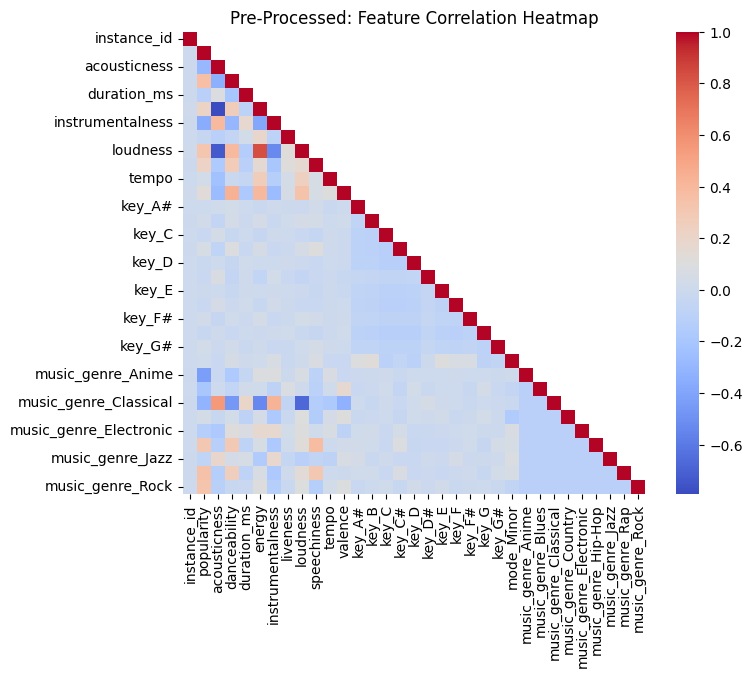

In [41]:
# view new correlation matrix
processed_corr = processed_df.corr(numeric_only=True)

# create the heatmap
mask = np.triu(np.ones_like(processed_corr, dtype=float), k=1)

plt.figure(figsize=(8, 6))
sns.heatmap(processed_corr, mask=mask, cmap='coolwarm', annot=False, square=True)
plt.title('Pre-Processed: Feature Correlation Heatmap')
plt.show()

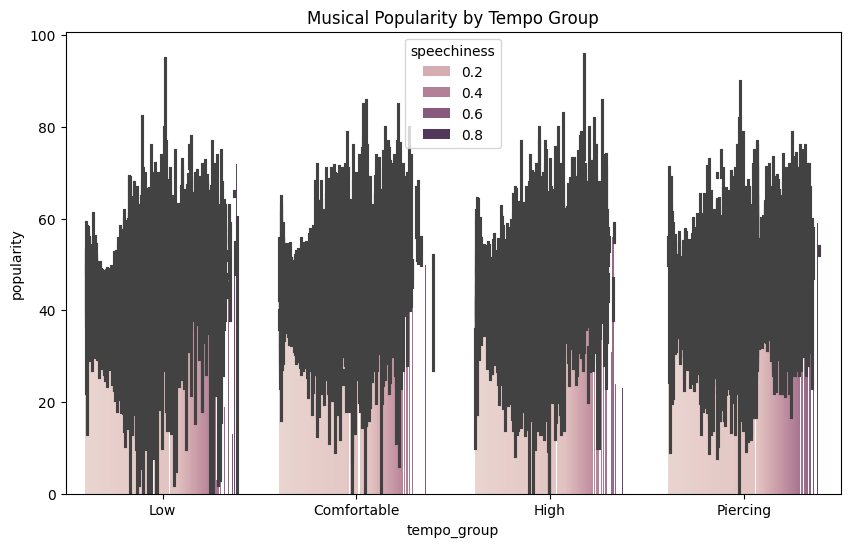

In [42]:
# tempo vs popularity
plt.figure(figsize=(10, 6))
# https://seaborn.pydata.org/generated/seaborn.barplot.html
sns.barplot(data=processed_df, x='tempo_group', y='popularity', hue="speechiness")
ax.set_xticks(())
ax.set_yticks(())
plt.title('Musical Popularity by Tempo Group')
plt.show()

## Combine features

In [45]:
# combine highly correlated features into one
# reduce dimensionality

# remove the columns that won't be used for any prediction
processed_df = processed_df.drop(columns=['instance_id', 'obtained_date'])
print(f"Data shape after dropping columns: {processed_df.shape}")

# millisecond duration is converted to minutes, and dropped
processed_df['duration_min'] = processed_df['duration_ms'] / 60000
processed_df = processed_df.drop(columns=['duration_ms'])

# energy and danceability are merged
processed_df['energy_danceability'] = processed_df['energy'] * processed_df['danceability']

# energy and valence are merged
processed_df['energy_valence'] = processed_df['energy'] * processed_df['valence']

# acousticness and instrumentalness are merged
processed_df['acoustic_instrumental'] = processed_df['acousticness'] * processed_df['instrumentalness']

# drop tempo, and keep the tempo_group
processed_df = processed_df.dropna(subset=['tempo']).reset_index(drop=True)

# print the latest data
processed_df.head(10)

Data shape after dropping columns: (40560, 35)


,artist_name,track_name,popularity,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,...,music_genre_Electronic,music_genre_Hip-Hop,music_genre_Jazz,music_genre_Rap,music_genre_Rock,tempo_group,duration_min,energy_danceability,energy_valence,acoustic_instrumental
0,Thievery Corporation,The Shining Path,31.0,0.01270,0.622,0.890,0.950000,0.1240,-7.043,0.0300,...,True,False,False,False,False,Comfortable,3.638217,0.553580,0.472590,1.206500e-02
1,Dillon Francis,Hurricane,28.0,0.00306,0.620,0.755,0.011800,0.5340,-4.617,0.0345,...,True,False,False,False,False,High,3.593550,0.468100,0.251415,3.610800e-05
2,Dubloadz,Nitro,34.0,0.02540,0.774,0.700,0.002530,0.1570,-4.498,0.2390,...,True,False,False,False,False,High,2.781250,0.541800,0.189000,6.426200e-05
3,What So Not,Divide & Conquer,32.0,0.00465,0.638,0.587,0.909000,0.1570,-6.266,0.0413,...,True,False,False,False,False,Piercing,3.706150,0.374506,0.189601,4.226850e-03
4,Jordan Comolli,Clash,46.0,0.02890,0.572,0.803,0.000008,0.1060,-4.294,0.3510,...,True,False,False,False,False,Piercing,3.573467,0.459316,0.184690,2.236860e-07
5,Hraach,Delirio,43.0,0.02970,0.809,0.706,0.903000,0.0635,-9.339,0.0484,...,True,False,False,False,False,High,6.935533,0.571154,0.537266,2.681910e-02
6,Kayzo,NEVER ALONE,39.0,0.00299,0.509,0.921,0.000276,0.1780,-3.175,0.2680,...,True,False,False,False,False,Piercing,4.880000,0.468789,0.251433,8.252400e-07
7,Shlump,Lazer Beam,22.0,0.00934,0.578,0.731,0.011200,0.1110,-7.091,0.1730,...,True,False,False,False,False,High,3.413333,0.422518,0.148393,1.046080e-04
8,Chase & Status,Lost & Not Found - Acoustic,30.0,0.85500,0.607,0.158,0.000000,0.1060,-13.787,0.0345,...,True,False,False,False,False,Low,2.841050,0.095906,0.048506,0.000000e+00
9,G Jones,Mind,27.0,0.03370,0.513,0.828,0.569000,0.1090,-5.439,0.0609,...,True,False,False,False,False,Piercing,2.752200,0.424764,0.048935,1.917530e-02


In [46]:
# drop duplicates based on track & artist name
processed_df = processed_df.drop_duplicates(subset=['artist_name', 'track_name'], keep='last')
print(f" Shape after dropping duplicate track and artist: {processed_df.shape}")

 Shape after dropping duplicate track and artist: (37967, 38)


In [47]:
processed_df.head(10)

,artist_name,track_name,popularity,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,...,music_genre_Electronic,music_genre_Hip-Hop,music_genre_Jazz,music_genre_Rap,music_genre_Rock,tempo_group,duration_min,energy_danceability,energy_valence,acoustic_instrumental
0,Thievery Corporation,The Shining Path,31.0,0.01270,0.622,0.890,0.950000,0.1240,-7.043,0.0300,...,True,False,False,False,False,Comfortable,3.638217,0.553580,0.472590,1.206500e-02
1,Dillon Francis,Hurricane,28.0,0.00306,0.620,0.755,0.011800,0.5340,-4.617,0.0345,...,True,False,False,False,False,High,3.593550,0.468100,0.251415,3.610800e-05
2,Dubloadz,Nitro,34.0,0.02540,0.774,0.700,0.002530,0.1570,-4.498,0.2390,...,True,False,False,False,False,High,2.781250,0.541800,0.189000,6.426200e-05
3,What So Not,Divide & Conquer,32.0,0.00465,0.638,0.587,0.909000,0.1570,-6.266,0.0413,...,True,False,False,False,False,Piercing,3.706150,0.374506,0.189601,4.226850e-03
4,Jordan Comolli,Clash,46.0,0.02890,0.572,0.803,0.000008,0.1060,-4.294,0.3510,...,True,False,False,False,False,Piercing,3.573467,0.459316,0.184690,2.236860e-07
5,Hraach,Delirio,43.0,0.02970,0.809,0.706,0.903000,0.0635,-9.339,0.0484,...,True,False,False,False,False,High,6.935533,0.571154,0.537266,2.681910e-02
6,Kayzo,NEVER ALONE,39.0,0.00299,0.509,0.921,0.000276,0.1780,-3.175,0.2680,...,True,False,False,False,False,Piercing,4.880000,0.468789,0.251433,8.252400e-07
7,Shlump,Lazer Beam,22.0,0.00934,0.578,0.731,0.011200,0.1110,-7.091,0.1730,...,True,False,False,False,False,High,3.413333,0.422518,0.148393,1.046080e-04
8,Chase & Status,Lost & Not Found - Acoustic,30.0,0.85500,0.607,0.158,0.000000,0.1060,-13.787,0.0345,...,True,False,False,False,False,Low,2.841050,0.095906,0.048506,0.000000e+00
9,G Jones,Mind,27.0,0.03370,0.513,0.828,0.569000,0.1090,-5.439,0.0609,...,True,False,False,False,False,Piercing,2.752200,0.424764,0.048935,1.917530e-02


In [49]:
# save the final cleaned data
processed_df.to_csv("./ub_music_genre_final_v3.csv")

## Model, and fitting data

In [50]:
# _TARGET = "popularity"
_TARGET = "tempo_group"
_NN_count = 5
_RANDOM_STATE = 42

In [51]:

model_map = {
    "Nearest Neighbors": KNeighborsClassifier(_NN_count),  # KNN with 5 neighbours
    "Linear SVM": SVC(kernel="linear", C=0.025, random_state=_RANDOM_STATE),
    "Logistic Regression": LogisticRegression(),
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(max_depth=_NN_count, random_state=_RANDOM_STATE),
    "Random Forest": RandomForestClassifier(
        max_depth=_NN_count, n_estimators=10, max_features=1, random_state=_RANDOM_STATE
    ),  # ensemble method
    "Neural Net":  MLPClassifier(alpha=1, max_iter=400, random_state=_RANDOM_STATE),  # neural net
}

In [52]:
# copy the processed data for before feature selection and test train split
transformed_df = processed_df.copy()

# drop artist name and track name
transformed_df.drop(columns=['artist_name', 'track_name'], inplace=True)

transformed_df.head()

,popularity,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,...,music_genre_Electronic,music_genre_Hip-Hop,music_genre_Jazz,music_genre_Rap,music_genre_Rock,tempo_group,duration_min,energy_danceability,energy_valence,acoustic_instrumental
0,31.0,0.01270,0.622,0.890,0.950000,0.124,-7.043,0.0300,115.002,0.531,...,True,False,False,False,False,Comfortable,3.638217,0.553580,0.472590,1.206500e-02
1,28.0,0.00306,0.620,0.755,0.011800,0.534,-4.617,0.0345,127.994,0.333,...,True,False,False,False,False,High,3.593550,0.468100,0.251415,3.610800e-05
2,34.0,0.02540,0.774,0.700,0.002530,0.157,-4.498,0.2390,128.014,0.270,...,True,False,False,False,False,High,2.781250,0.541800,0.189000,6.426200e-05
3,32.0,0.00465,0.638,0.587,0.909000,0.157,-6.266,0.0413,145.036,0.323,...,True,False,False,False,False,Piercing,3.706150,0.374506,0.189601,4.226850e-03
4,46.0,0.02890,0.572,0.803,0.000008,0.106,-4.294,0.3510,149.995,0.230,...,True,False,False,False,False,Piercing,3.573467,0.459316,0.184690,2.236860e-07


In [69]:
# split the dataset in 80% train, 20% test
# following the naming convention for data for model
##  y = target label
##  X = feature labels
le = LabelEncoder()

y = transformed_df[_TARGET]
y = pd.DataFrame(le.fit_transform(y)).values.ravel()
X = transformed_df.drop(_TARGET, axis=1)
X.drop(columns=['tempo'], inplace=True)

se = StandardScaler()
numerical_cols = X.columns[X.dtypes != object]

# split data to test and train
X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.8, test_size=0.2, random_state=_RANDOM_STATE
)

X_train_scaled = X_train
X_test_scaled = X_test
X_train_scaled[numerical_cols] = se.fit_transform(X_train[numerical_cols])
X_test_scaled[numerical_cols] = se.transform(X_test[numerical_cols])
X_train_selected = X_train_scaled[numerical_cols]
X_test_selected = X_test_scaled[numerical_cols]


print(f"Test data shape: {X_test.shape} : \n{X_test.head()}")
print("-----------------------------------------------------")
print(f"Train data shape: {X_train.shape} : \n{X_train.head()}")

Test data shape: (7594, 34) : 
       popularity  acousticness  danceability    energy  instrumentalness  \
32169    0.681682     -0.829387     -0.232040  0.908735         -0.143517   
287      0.359964     -0.904143      1.260167  1.254794          1.865855   
35044   -0.347815      1.791292     -1.174486 -1.949423          2.155930   
22772    0.874712      0.261454     -0.232040 -0.628069         -0.319677   
4555    -1.763372     -0.652400     -0.450822  0.387784          0.385265   

       liveness  loudness  speechiness   valence    key_A#  ...  \
32169 -0.716860  0.389462    -0.447824 -1.595236 -0.267765  ...   
287    2.506050  0.563531     1.235452  0.328819 -0.267765  ...   
35044 -0.901641 -1.242006    -0.541228 -1.303859 -0.267765  ...   
22772 -0.590400  0.306866    -0.635636 -1.061382 -0.267765  ...   
4555  -0.422194 -0.173808    -0.131456 -1.291736 -0.267765  ...   

       music_genre_Country  music_genre_Electronic  music_genre_Hip-Hop  \
32169            -0.334655  

In [ ]:
#X.iloc[:, 0].max()
# x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
# y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

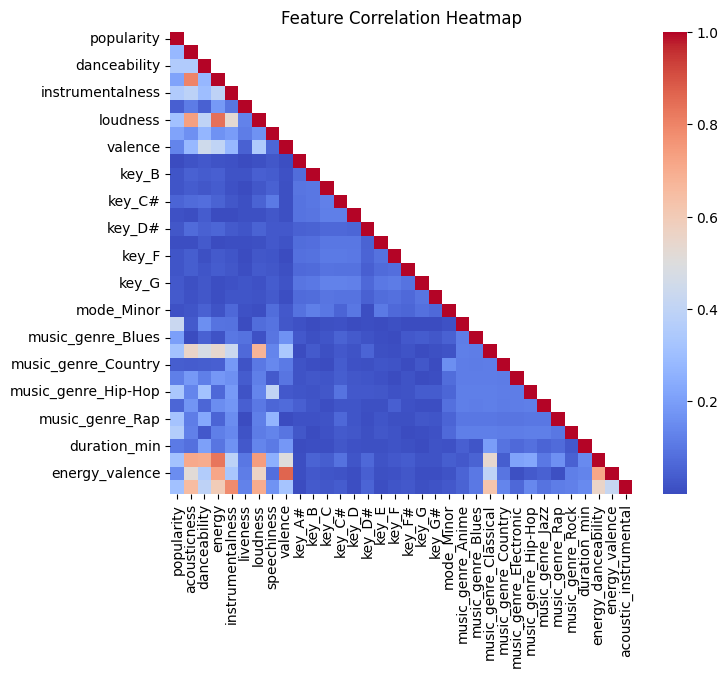

In [63]:
# Correlation matrix to explore target, from Pumi
feature_corr_matrix = X.corr().abs()

mask = np.triu(np.ones_like(feature_corr_matrix, dtype=float), k=1)

plt.figure(figsize=(8, 6))
sns.heatmap(feature_corr_matrix, mask=mask, cmap='coolwarm', annot=False, square=True)
plt.title('Feature Correlation Heatmap')
plt.show()

In [64]:
# Mutual info

# discrete/categorical features
discrete_features = X.columns.str.startswith(('key_', 'mode_', 'music_'))
mutual_info_all = mutual_info_classif(
    X, y,
    discrete_features=discrete_features,
    random_state=_RANDOM_STATE
)
mutual_info_all = pd.Series(mutual_info_all)
mutual_info_all.index = X.columns
mutual_info_all.sort_values(ascending=False, inplace=True)

print(f"Mutual info on whole data: \n{mutual_info_all}")

Mutual info on whole data: 
energy_danceability       0.053903
danceability              0.053808
energy                    0.042446
acousticness              0.040898
loudness                  0.037778
energy_valence            0.037234
speechiness               0.024257
acoustic_instrumental     0.022931
valence                   0.022677
music_genre_Classical     0.016349
duration_min              0.011809
instrumentalness          0.010505
music_genre_Jazz          0.006640
music_genre_Electronic    0.006138
music_genre_Anime         0.002475
music_genre_Rock          0.001350
music_genre_Country       0.001146
music_genre_Blues         0.001142
popularity                0.001023
liveness                  0.000713
music_genre_Hip-Hop       0.000657
music_genre_Rap           0.000368
mode_Minor                0.000288
key_A#                    0.000275
key_C#                    0.000155
key_D#                    0.000138
key_G                     0.000123
key_C                     0

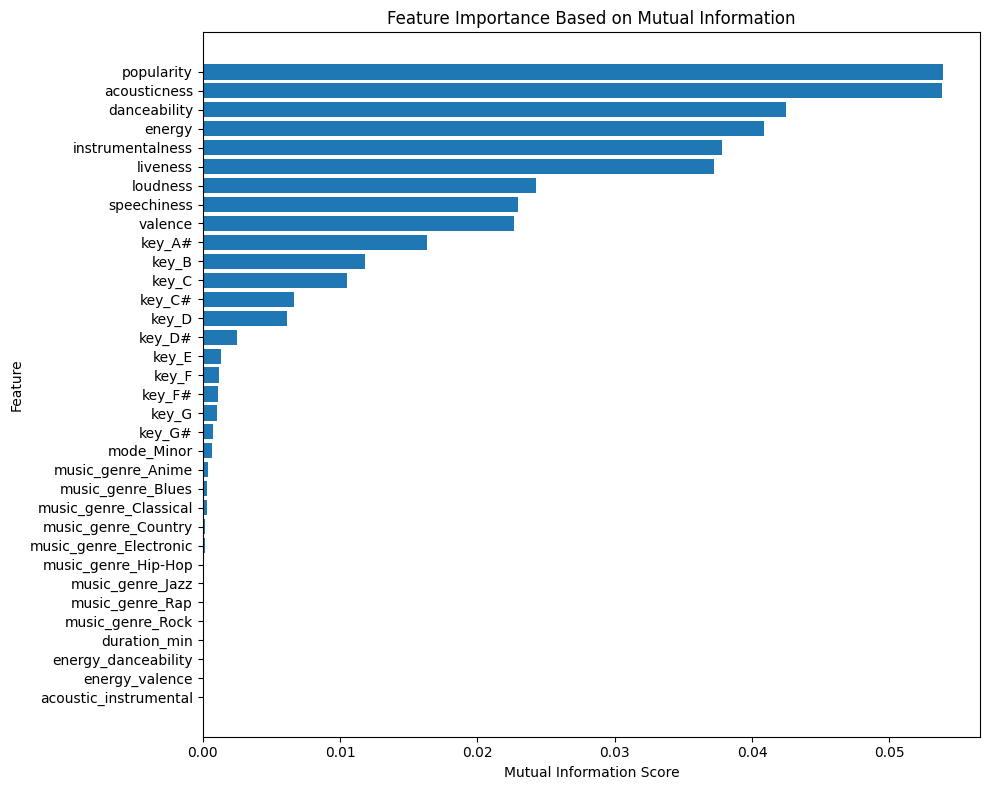

In [65]:
mi_df = pd.DataFrame({
    'Feature': X.columns,
    'MI Score': mutual_info_all
})

mi_df = mi_df.sort_values(by='MI Score', ascending=False)

plt.figure(figsize=(10, 8))
plt.barh(mi_df['Feature'], mi_df['MI Score'])

plt.xlabel("Mutual Information Score")
plt.ylabel("Feature")
plt.title("Feature Importance Based on Mutual Information")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [66]:
# select feature by k-fold, for the classifiers
# ref: https://medium.com/@agdop.mi/feature-engineering-and-selection-with-scikit-learn-fe5d3c737147
from sklearn.feature_selection import SelectKBest, f_classif

le = LabelEncoder()

clf_selector = SelectKBest(score_func=f_classif, k=5)
new_transformed_df = transformed_df.copy()
encoded_target = pd.DataFrame(le.fit_transform(new_transformed_df[_TARGET]))
new_transformed_df[_TARGET] = encoded_target
new_transformed_df.drop(columns=['tempo'], inplace=True)
new_transformed_df = new_transformed_df.dropna()

# print(new_transformed_df[_TARGET])

clf_selector_df = clf_selector.fit_transform(
    new_transformed_df, new_transformed_df[_TARGET])

# print(f"Selected support: {clf_selector.get_support()}")

clf_selected_features = new_transformed_df.columns[clf_selector.get_support()]
print()
print(f" Selected features: {clf_selected_features}")
print()


 Selected features: Index(['acousticness', 'music_genre_Electronic', 'music_genre_Jazz',
       'music_genre_Rock', 'tempo_group'],
      dtype='str')



/Users/pops/spaces/unimelbprtc/music_ml/udita/.uvenv/lib/python3.13/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: divide by zero encountered in divide
  f = msb / msw


### Feature selection with K-folds

In [67]:
transformed_df.shape

(37967, 36)

In [70]:
## RFE to select feature
# Ref: https://scikit-learn.org/stable/auto_examples/feature_selection/plot_rfe_with_cross_validation.html#sphx-glr-auto-examples-feature-selection-plot-rfe-with-cross-validation-py

from sklearn.feature_selection import RFECV
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold

min_features_to_select = 1 # Minimum number of features to consider
clf = LogisticRegression(max_iter=500)
cv = StratifiedKFold(10)

rfecv = RFECV(
    estimator=clf,
    step=1,
    cv=cv,
    scoring="accuracy",
    min_features_to_select=min_features_to_select,
    n_jobs=2,
)
rfecv.fit(X_train_scaled, y_train)

print(f"Optimal number of features: {rfecv.n_features_}")


Optimal number of features: 19


In [71]:
# view the features
print(f"The optimal feature set: {rfecv.support_}")

The optimal feature set: [ True  True  True  True  True False  True  True  True False False False
  True False False False False False False False False  True  True False
  True  True  True  True  True False  True  True  True False]


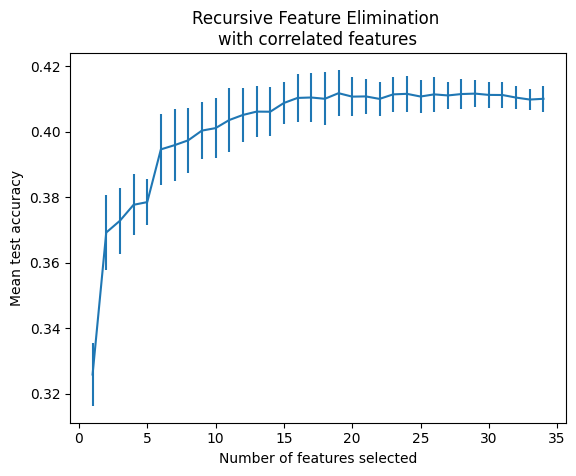

In [72]:
# plot the number of features vs cross-validation

ft_data = {
    key: value
    for key, value in rfecv.cv_results_.items()
    if key in ["n_features", "mean_test_score", "std_test_score"]
}
cv_results = pd.DataFrame(ft_data)
plt.figure()
plt.xlabel("Number of features selected")
plt.ylabel("Mean test accuracy")
plt.errorbar(
    x=cv_results["n_features"],
    y=cv_results["mean_test_score"],
    yerr=cv_results["std_test_score"],
)
plt.title("Recursive Feature Elimination \nwith correlated features")
plt.show()

In [79]:
# optimal features at every step
feat_names = [nm for nm, v in X.items()]

# print(feat_names)

final_set_of_features = set([])

for i in range(cv.n_splits):
    mask = rfecv.cv_results_[f"split{i}_support"][
        rfecv.n_features_ - 1
    ]  # mask of features selected by the RFE
    features_selected = np.ma.compressed(np.ma.masked_array(feat_names, mask=1 - mask))
    print(f"Features selected in fold {i}: {features_selected}")
    print()


Features selected in fold 0: ['popularity' 'acousticness' 'danceability' 'energy' 'instrumentalness'
 'loudness' 'speechiness' 'valence' 'key_C#' 'key_E' 'music_genre_Anime'
 'music_genre_Blues' 'music_genre_Country' 'music_genre_Electronic'
 'music_genre_Hip-Hop' 'music_genre_Jazz' 'duration_min'
 'energy_danceability' 'energy_valence']

Features selected in fold 1: ['popularity' 'acousticness' 'danceability' 'energy' 'instrumentalness'
 'loudness' 'speechiness' 'valence' 'key_C#' 'music_genre_Anime'
 'music_genre_Blues' 'music_genre_Country' 'music_genre_Electronic'
 'music_genre_Hip-Hop' 'music_genre_Jazz' 'music_genre_Rap' 'duration_min'
 'energy_danceability' 'energy_valence']

Features selected in fold 2: ['popularity' 'acousticness' 'danceability' 'energy' 'instrumentalness'
 'liveness' 'loudness' 'speechiness' 'valence' 'music_genre_Anime'
 'music_genre_Blues' 'music_genre_Country' 'music_genre_Electronic'
 'music_genre_Hip-Hop' 'music_genre_Jazz' 'music_genre_Rap' 'duration_mi

In [85]:
# select most important features
# Ref: https://www.geeksforgeeks.org/machine-learning/how-to-identify-the-most-informative-features-for-scikit-learn-classifiers/
selected_features = rfecv.support_
final_set_of_features = [feat_names[i] for i in range(len(feat_names)) if selected_features[i]]
print(f"Selected features : {final_set_of_features}")


Selected features : ['popularity', 'acousticness', 'danceability', 'energy', 'instrumentalness', 'loudness', 'speechiness', 'valence', 'key_C#', 'music_genre_Anime', 'music_genre_Blues', 'music_genre_Country', 'music_genre_Electronic', 'music_genre_Hip-Hop', 'music_genre_Jazz', 'music_genre_Rap', 'duration_min', 'energy_danceability', 'energy_valence']


## Create pipeline and fit models


In [86]:
# cross validation
cross_validation = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=_RANDOM_STATE
)

In [89]:
# data for only selected features
X_train_selected = X_train_scaled[final_set_of_features]
X_test_selected =X_test_scaled[final_set_of_features]


In [90]:
model_map = {
    "Nearest Neighbors": KNeighborsClassifier(_NN_count),  # KNN with 5 neighbours
    "Linear SVM": SVC(kernel="linear", C=0.025, random_state=_RANDOM_STATE),
    # "Logistic Regression": LogisticRegression(),
    # "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(max_depth=_NN_count, random_state=_RANDOM_STATE),
    "Random Forest": RandomForestClassifier(
        max_depth=_NN_count, n_estimators=10, max_features=1, random_state=_RANDOM_STATE
    ),  # ensemble method
    "Neural Net":  MLPClassifier(alpha=1, max_iter=400, random_state=_RANDOM_STATE),  # neural net
}

# with feature selection
# plot confusion matrix

Without Feature Selection: Trained model: Nearest Neighbors
Without Feature Selection: Nearest Neighbors : 35.26
Accuracy: 0.35264682644192785
Confusion Matrix:

[[814 474 407 284   0]
 [601 532 342 272   1]
 [555 333 708 313   0]
 [522 393 384 624   0]
 [  8   4   7  16   0]]
              precision    recall  f1-score   support

           0       0.33      0.41      0.36      1979
           1       0.31      0.30      0.31      1748
           2       0.38      0.37      0.38      1909
           3       0.41      0.32      0.36      1923
           4       0.00      0.00      0.00        35

    accuracy                           0.35      7594
   macro avg       0.29      0.28      0.28      7594
weighted avg       0.36      0.35      0.35      7594

--------------------------------------------------------
Without Feature Selection: Trained model: Linear SVM
Without Feature Selection: Linear SVM : 41.35
Accuracy: 0.4134843297340005
Confusion Matrix:

[[ 861  339  372  407    0]
 

/Users/pops/spaces/unimelbprtc/music_ml/udita/.uvenv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/pops/spaces/unimelbprtc/music_ml/udita/.uvenv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/pops/spaces/unimelbprtc/music_ml/udita/.uvenv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control thi

Without Feature Selection: Trained model: Random Forest
Without Feature Selection: Random Forest : 36.32
Accuracy: 0.36318145904661575
Confusion Matrix:

[[ 592    7  452  928    0]
 [ 384   15  352  997    0]
 [ 317    6  770  816    0]
 [ 271    2  269 1381    0]
 [   9    0    8   18    0]]
              precision    recall  f1-score   support

           0       0.38      0.30      0.33      1979
           1       0.50      0.01      0.02      1748
           2       0.42      0.40      0.41      1909
           3       0.33      0.72      0.46      1923
           4       0.00      0.00      0.00        35

    accuracy                           0.36      7594
   macro avg       0.33      0.29      0.24      7594
weighted avg       0.40      0.36      0.31      7594

--------------------------------------------------------


/Users/pops/spaces/unimelbprtc/music_ml/udita/.uvenv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/pops/spaces/unimelbprtc/music_ml/udita/.uvenv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/pops/spaces/unimelbprtc/music_ml/udita/.uvenv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control thi

Without Feature Selection: Trained model: Neural Net
Without Feature Selection: Neural Net : 42.63
Accuracy: 0.4262575717671846
Confusion Matrix:

[[1039  145  384  411    0]
 [ 734  219  332  463    0]
 [ 504   60  813  532    0]
 [ 336  112  309 1166    0]
 [   2    0    4   29    0]]
              precision    recall  f1-score   support

           0       0.40      0.53      0.45      1979
           1       0.41      0.13      0.19      1748
           2       0.44      0.43      0.43      1909
           3       0.45      0.61      0.52      1923
           4       0.00      0.00      0.00        35

    accuracy                           0.43      7594
   macro avg       0.34      0.34      0.32      7594
weighted avg       0.42      0.43      0.40      7594

--------------------------------------------------------


/Users/pops/spaces/unimelbprtc/music_ml/udita/.uvenv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/pops/spaces/unimelbprtc/music_ml/udita/.uvenv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/pops/spaces/unimelbprtc/music_ml/udita/.uvenv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control thi

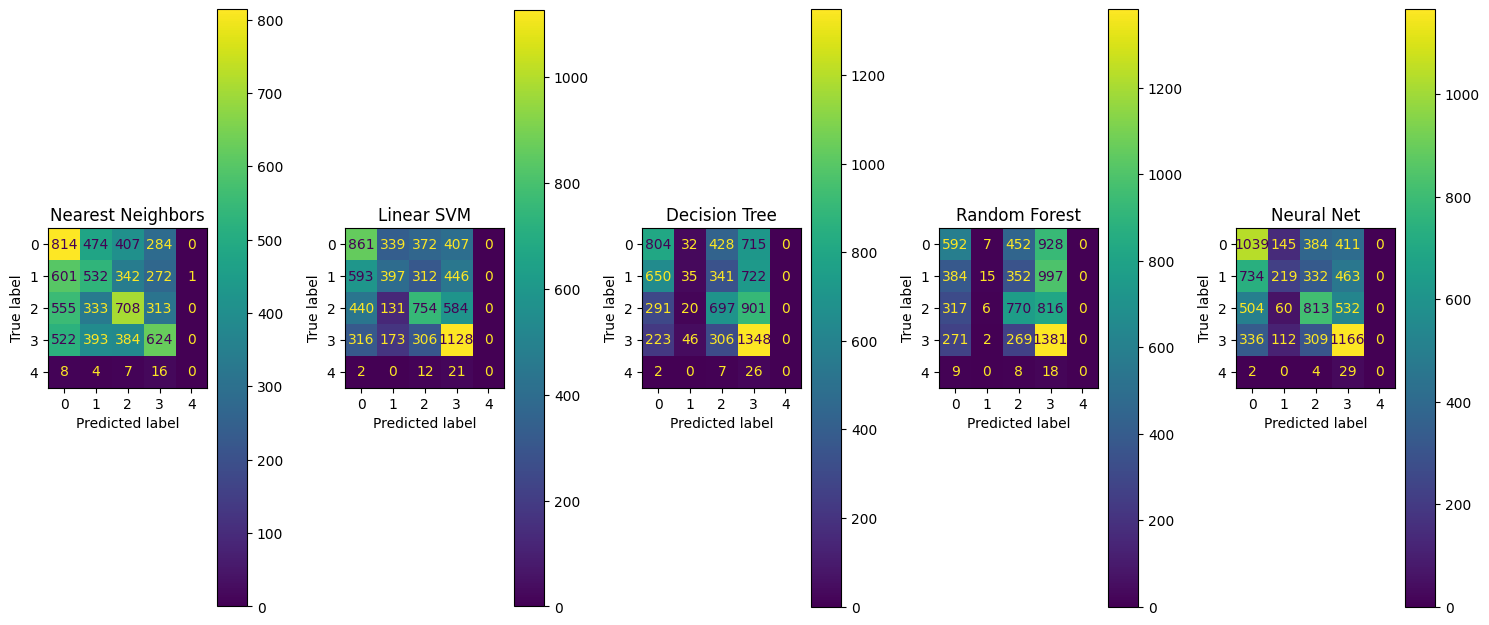

In [110]:
# without feature selection

fig, axes = plt.subplots(nrows=1, ncols=len(model_map), figsize=(15,10))

# print(axes)
# confusion_mat_wo_ft_selection = {}
col = 0
for model_name, model in model_map.items():
    model.fit(X_train, y_train)
    print(f"Without Feature Selection: Trained model: {model_name}")
    print(f"Without Feature Selection: {model_name} : {round(model.score(X_test, y_test) * 100, 2)}")

    predicted_y = model.predict(X_test)
    print("Accuracy:", accuracy_score(y_test, predicted_y))

    cm = confusion_matrix(y_test, predicted_y)
    print("Confusion Matrix:\n")
    print(cm)
    print(classification_report(y_test, predicted_y))
    print("--------------------------------------------------------")

    ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=model.classes_).plot(ax=axes[col])
    axes[col].set_title(f"{model_name}")
    col += 1

plt.tight_layout()
plt.show()


Scaled data: Trained model: Nearest Neighbors
Scaled data: Nearest Neighbors : 35.26
--------------------------------------------------------
Accuracy: 0.35264682644192785
Confusion Matrix:

[[814 474 407 284   0]
 [601 532 342 272   1]
 [555 333 708 313   0]
 [522 393 384 624   0]
 [  8   4   7  16   0]]
              precision    recall  f1-score   support

           0       0.33      0.41      0.36      1979
           1       0.31      0.30      0.31      1748
           2       0.38      0.37      0.38      1909
           3       0.41      0.32      0.36      1923
           4       0.00      0.00      0.00        35

    accuracy                           0.35      7594
   macro avg       0.29      0.28      0.28      7594
weighted avg       0.36      0.35      0.35      7594

--------------------------------------------------------
Scaled data: Trained model: Linear SVM
Scaled data: Linear SVM : 41.35
--------------------------------------------------------
Accuracy: 0.4134843

/Users/pops/spaces/unimelbprtc/music_ml/udita/.uvenv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/pops/spaces/unimelbprtc/music_ml/udita/.uvenv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/pops/spaces/unimelbprtc/music_ml/udita/.uvenv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control thi

Scaled data: Trained model: Random Forest
Scaled data: Random Forest : 36.32
--------------------------------------------------------
Accuracy: 0.36318145904661575
Confusion Matrix:

[[ 592    7  452  928    0]
 [ 384   15  352  997    0]
 [ 317    6  770  816    0]
 [ 271    2  269 1381    0]
 [   9    0    8   18    0]]
              precision    recall  f1-score   support

           0       0.38      0.30      0.33      1979
           1       0.50      0.01      0.02      1748
           2       0.42      0.40      0.41      1909
           3       0.33      0.72      0.46      1923
           4       0.00      0.00      0.00        35

    accuracy                           0.36      7594
   macro avg       0.33      0.29      0.24      7594
weighted avg       0.40      0.36      0.31      7594

--------------------------------------------------------


/Users/pops/spaces/unimelbprtc/music_ml/udita/.uvenv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/pops/spaces/unimelbprtc/music_ml/udita/.uvenv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/pops/spaces/unimelbprtc/music_ml/udita/.uvenv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control thi

Scaled data: Trained model: Neural Net
Scaled data: Neural Net : 42.63
--------------------------------------------------------
Accuracy: 0.4262575717671846
Confusion Matrix:

[[1039  145  384  411    0]
 [ 734  219  332  463    0]
 [ 504   60  813  532    0]
 [ 336  112  309 1166    0]
 [   2    0    4   29    0]]
              precision    recall  f1-score   support

           0       0.40      0.53      0.45      1979
           1       0.41      0.13      0.19      1748
           2       0.44      0.43      0.43      1909
           3       0.45      0.61      0.52      1923
           4       0.00      0.00      0.00        35

    accuracy                           0.43      7594
   macro avg       0.34      0.34      0.32      7594
weighted avg       0.42      0.43      0.40      7594

--------------------------------------------------------


/Users/pops/spaces/unimelbprtc/music_ml/udita/.uvenv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/pops/spaces/unimelbprtc/music_ml/udita/.uvenv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/pops/spaces/unimelbprtc/music_ml/udita/.uvenv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control thi

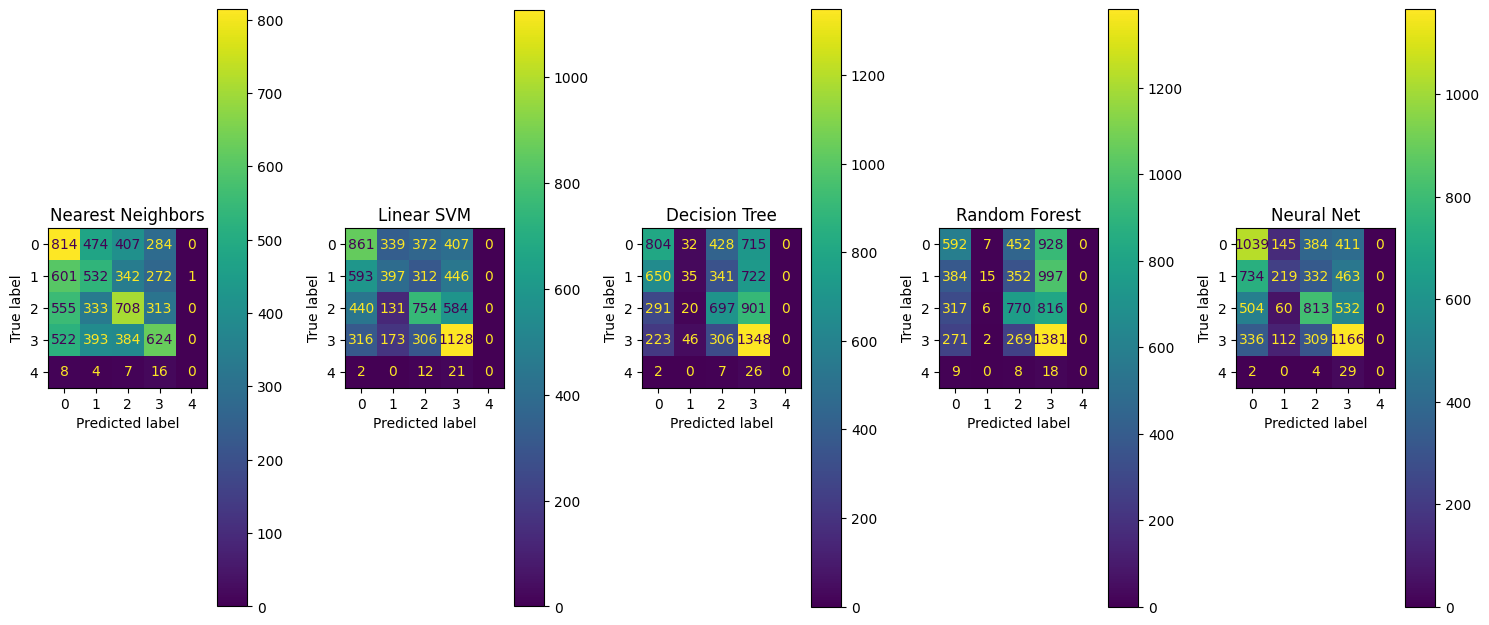

In [111]:
# fit, prdict, score scaled data
fig, axes = plt.subplots(nrows=1, ncols=len(model_map), figsize=(15,10))

col = 0
for model_name, model in model_map.items():
    model.fit(X_train_scaled, y_train)
    print(f"Scaled data: Trained model: {model_name}")
    print(f"Scaled data: {model_name} : {round(model.score(X_test_scaled, y_test) * 100, 2)}")
    print("--------------------------------------------------------")

    predicted_y = model.predict(X_test_scaled)
    print("Accuracy:", accuracy_score(y_test, predicted_y))

    cm = confusion_matrix(y_test, predicted_y)
    print("Confusion Matrix:\n")
    print(cm)
    print(classification_report(y_test, predicted_y))
    print("--------------------------------------------------------")

    ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=model.classes_).plot(ax=axes[col])
    axes[col].set_title(f"{model_name}")
    col += 1

plt.tight_layout()
plt.show()

Feature Selection: Trained model: Nearest Neighbors
Feature Selection: Nearest Neighbors : 36.9
--------------------------------------------------------
Accuracy: 0.3689755069791941
Confusion Matrix:

[[843 473 402 261   0]
 [672 508 284 283   1]
 [525 306 768 309   1]
 [438 386 412 683   4]
 [  9   2   6  18   0]]
              precision    recall  f1-score   support

           0       0.34      0.43      0.38      1979
           1       0.30      0.29      0.30      1748
           2       0.41      0.40      0.41      1909
           3       0.44      0.36      0.39      1923
           4       0.00      0.00      0.00        35

    accuracy                           0.37      7594
   macro avg       0.30      0.29      0.29      7594
weighted avg       0.37      0.37      0.37      7594

--------------------------------------------------------
Feature Selection: Trained model: Linear SVM
Feature Selection: Linear SVM : 41.19
------------------------------------------------------

/Users/pops/spaces/unimelbprtc/music_ml/udita/.uvenv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/pops/spaces/unimelbprtc/music_ml/udita/.uvenv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/pops/spaces/unimelbprtc/music_ml/udita/.uvenv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control thi

Feature Selection: Trained model: Random Forest
Feature Selection: Random Forest : 38.48
--------------------------------------------------------
Accuracy: 0.38477745588622597
Confusion Matrix:

[[ 806   61  411  701    0]
 [ 534  105  318  791    0]
 [ 429   15  736  729    0]
 [ 349   42  257 1275    0]
 [   7    0    6   22    0]]
              precision    recall  f1-score   support

           0       0.38      0.41      0.39      1979
           1       0.47      0.06      0.11      1748
           2       0.43      0.39      0.40      1909
           3       0.36      0.66      0.47      1923
           4       0.00      0.00      0.00        35

    accuracy                           0.38      7594
   macro avg       0.33      0.30      0.27      7594
weighted avg       0.41      0.38      0.35      7594

--------------------------------------------------------


/Users/pops/spaces/unimelbprtc/music_ml/udita/.uvenv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/pops/spaces/unimelbprtc/music_ml/udita/.uvenv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/pops/spaces/unimelbprtc/music_ml/udita/.uvenv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control thi

Feature Selection: Trained model: Neural Net
Feature Selection: Neural Net : 42.92
--------------------------------------------------------
Accuracy: 0.4291545957334738
Confusion Matrix:

[[ 858  330  386  405    0]
 [ 553  417  330  448    0]
 [ 394  139  854  522    0]
 [ 266  197  330 1130    0]
 [   2    0    5   28    0]]
              precision    recall  f1-score   support

           0       0.41      0.43      0.42      1979
           1       0.39      0.24      0.29      1748
           2       0.45      0.45      0.45      1909
           3       0.45      0.59      0.51      1923
           4       0.00      0.00      0.00        35

    accuracy                           0.43      7594
   macro avg       0.34      0.34      0.33      7594
weighted avg       0.42      0.43      0.42      7594

--------------------------------------------------------


/Users/pops/spaces/unimelbprtc/music_ml/udita/.uvenv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/pops/spaces/unimelbprtc/music_ml/udita/.uvenv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/pops/spaces/unimelbprtc/music_ml/udita/.uvenv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control thi

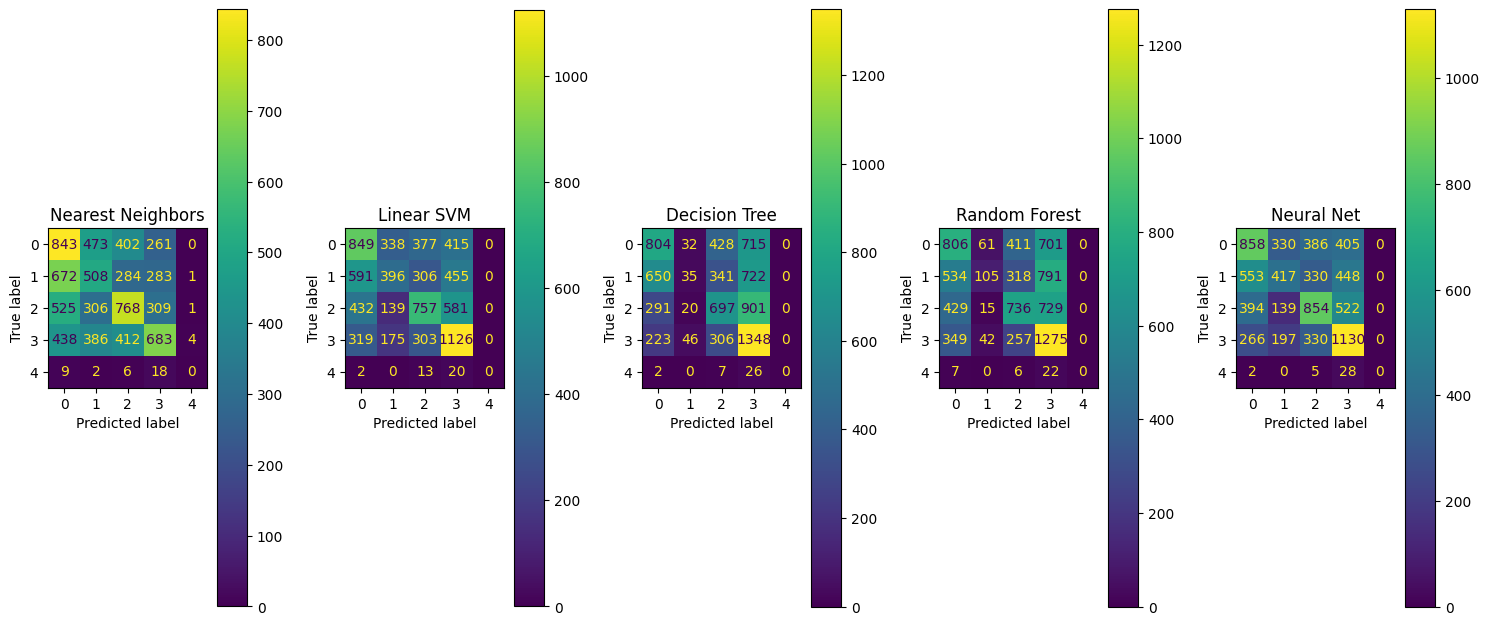

In [113]:
fig, axes = plt.subplots(nrows=1, ncols=len(model_map), figsize=(15,10))

col = 0
for model_name, model in model_map.items():
    model.fit(X_train_selected, y_train)
    print(f"Feature Selection: Trained model: {model_name}")
    print(f"Feature Selection: {model_name} : {round(model.score(X_test_selected, y_test) * 100, 2)}")
    print("--------------------------------------------------------")

    predicted_y = model.predict(X_test_selected)
    print("Accuracy:", accuracy_score(y_test, predicted_y))

    cm = confusion_matrix(y_test, predicted_y)
    print("Confusion Matrix:\n")
    print(cm)
    print(classification_report(y_test, predicted_y))
    print("--------------------------------------------------------")

    ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=model.classes_).plot(ax=axes[col])
    axes[col].set_title(f"{model_name}")
    col += 1

plt.tight_layout()
plt.show()

### Observation
- scaled data did not perform any better than non-scaled
- feature selection did not do significantly better than non-selected
- Linear SVM and Neural Net are the best ones
- Random forest did minimally better than Decision Tree

In [126]:
## Folds, Linear SVM, Selected Feature
# Ref: https://apxml.com/courses/getting-started-with-scikit-learn/chapter-5-model-selection-evaluation/stratified-kfold-classification
from sklearn.model_selection import cross_val_score

kfolds = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=_RANDOM_STATE
)
# for train_index, test_index in kfolds.split(X_train_selected, y_train):
#     # print(f"Fold {i}:")
#     print(f"  Train: index={train_index} :: len={len(train_index)}")
#     print(f"  Test:  index={test_index} :: len={len(test_index)}")

#     print("***************")
svc = SVC(kernel="linear", C=0.025, random_state=_RANDOM_STATE)
scores_explicit_skf = cross_val_score(svc, X_train_selected, y_train, cv=kfolds, scoring='accuracy')
print(f"\nAccuracy scores using explicit StratifiedKFold (5-fold): {scores_explicit_skf}")
print(f"Mean Accuracy: {scores_explicit_skf.mean():.4f} (+/- {scores_explicit_skf.std() * 2:.4f})")



Accuracy scores using explicit StratifiedKFold (5-fold): [0.41218107 0.4054321  0.41547325 0.40599276 0.41323675]
Mean Accuracy: 0.4105 (+/- 0.0081)


In [127]:
# Folds, NN, Selected Feature
mlp = MLPClassifier(alpha=1, max_iter=400, random_state=_RANDOM_STATE)
scores_explicit_skf = cross_val_score(mlp, X_train_selected, y_train, cv=kfolds, scoring='accuracy')
print(f"\nAccuracy scores using explicit StratifiedKFold (5-fold): {scores_explicit_skf}")
print(f"Mean Accuracy: {scores_explicit_skf.mean():.4f} (+/- {scores_explicit_skf.std() * 2:.4f})")



Accuracy scores using explicit StratifiedKFold (5-fold): [0.43358025 0.42255144 0.43308642 0.43266381 0.43546263]
Mean Accuracy: 0.4315 (+/- 0.0091)


In [ ]:
# Hyper Parameter tuning
# Define the parameter grid
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [1, 0.1, 0.01, 0.001],
    'kernel': ['rbf', 'linear']
}

gscv = GridSearchCV(
    estimator=svc,
    # scoring="accuracy",
    param_grid=param_grid,
    refit=True,
    verbose=1,
    cv=5,
    n_jobs=1
)

# Fit the model (it will try all combinations)
gscv.fit(X_train_selected, y_train)

print(f"Best Parameters: {gscv.best_params_}")
print(f"Best Score: {gscv.best_score_}")

# You can now use the 'grid' object to predict, as it has been refit with the best settings
predicted_y = gscv.predict(X_test_selected)

print(f"Feature Selection: Trained model: SVC : Selected Features: 5-folds: Tuned parameters")
print(f"Score: {round(gscv.score(X_test_selected, y_test) * 100, 2)}")
print("--------------------------------------------------------")

print("Accuracy:", accuracy_score(y_test, predicted_y))

cm = confusion_matrix(y_test, predicted_y)
print("Confusion Matrix:\n")
print(cm)
print(classification_report(y_test, predicted_y))
print("--------------------------------------------------------")

fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(15,10))

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=gscv.classes_).plot(ax=axes[0])
axes[0].set_title("SVC : Selected Features: 5-folds: Tuned parameters")

plt.tight_layout()
plt.show()


Fitting 5 folds for each of 32 candidates, totalling 160 fits
